Adapted from example code in Chapter 14 of *Machine Learning for Business Analytics: Concepts, Techniques, and Applications in Python* (Second Edition), Shmueli et al. (© 2025 John Wiley & Sons, Inc.)

 Modified for instructional use.

In [1]:
!pip install mlba
!pip install contextualbandits

import mlba
import pandas as pd
import random
import matplotlib.pyplot as plt
import numpy as np
from contextualbandits.online import LinUCB
from sklearn.linear_model import LogisticRegression

%matplotlib inline

no display found. Using non-interactive Agg backend


In [2]:
def load_and_process_movies():
    movies = mlba.load_data('MovieLensMovies.csv.gz')
    # convert |-separated genres into individual columns
    genres = movies['genres'].str.split('|', expand=True).stack()
    genres = pd.get_dummies(genres.reset_index(level=1, drop=True))
    genres = genres.groupby(level=0).sum().astype(int)
    return pd.concat([movies, genres], axis=1).drop(columns=['genres', '(no genres listed)'])

# load and combine ratings with movie information
movies = load_and_process_movies()
ratings = mlba.load_data('MovieLensRatings.csv.gz')
ratings['reward'] = [1 if rating >= 4.5 else 0 for rating in ratings['rating']]
ratings = ratings.sort_values('timestamp')
all_movies = ratings.merge(movies, on='movieId')

# find the top-50 most frequently rated movies and subset all_movies
top_50 = set(all_movies.value_counts('movieId').head(50).index)
top_50_movies = all_movies[all_movies['movieId'].isin(top_50)]

# create profile of genres for each movie in the top-50 (arm_features)
arm_features = (top_50_movies.drop(columns=['userId', 'reward', 'rating', 'timestamp', 'title'])
                .drop_duplicates(subset='movieId'))
arm_features = arm_features.set_index('movieId')

# for each user, create their profile of genre preferences based on
# their viewed movies that are not in the top-50 (user_features)
user_features = (all_movies[~all_movies['movieId'].isin(top_50)]
                 .drop(columns=['movieId', 'reward', 'rating', 'timestamp', 'title'])
                 .groupby('userId').sum())  # sum genres across movies
user_features = user_features.div(user_features.sum(axis=1), axis=0)  # normalize

# keep only users who rated top-50 movies
top_50_raters = top_50_movies['userId'].unique()
user_features = user_features[user_features.index.isin(top_50_raters)]

# create the observed reactions for each user-movie pair
reactions = all_movies[['userId', 'movieId', 'reward']]
reactions = reactions[reactions['movieId'].isin(top_50)]
reactions = reactions[reactions['userId'].isin(top_50_raters)]

In [3]:
arm_features

,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movieId,,,,,,,,,,,,,,,,,,,
165,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0
595,0,0,1,1,0,0,0,0,1,0,0,1,1,0,1,0,0,0,0
590,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
588,0,1,1,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0
592,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0
150,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0
380,1,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0
1,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
32,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0


In [4]:
user_features

,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
userId,,,,,,,,,,,,,,,,,,,
1,0.123355,0.121711,0.046053,0.067434,0.123355,0.062500,0.000000,0.093750,0.074013,0.001645,0.024671,0.000000,0.036184,0.024671,0.039474,0.050987,0.070724,0.029605,0.009868
2,0.136364,0.030303,0.000000,0.000000,0.106061,0.121212,0.045455,0.212121,0.000000,0.000000,0.015152,0.045455,0.000000,0.030303,0.015152,0.060606,0.151515,0.015152,0.015152
3,0.133333,0.104762,0.038095,0.047619,0.085714,0.019048,0.000000,0.142857,0.038095,0.000000,0.076190,0.000000,0.009524,0.009524,0.047619,0.142857,0.066667,0.038095,0.000000
4,0.039301,0.052402,0.008734,0.017467,0.218341,0.050218,0.004367,0.251092,0.039301,0.008734,0.004367,0.000000,0.030568,0.039301,0.122271,0.015284,0.061135,0.015284,0.021834
5,0.060606,0.030303,0.030303,0.075758,0.121212,0.090909,0.000000,0.257576,0.060606,0.000000,0.015152,0.000000,0.030303,0.000000,0.136364,0.015152,0.045455,0.015152,0.015152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,0.052096,0.051312,0.015668,0.018410,0.161379,0.048962,0.001958,0.267920,0.035253,0.003134,0.019193,0.006267,0.017235,0.033294,0.137877,0.026635,0.073247,0.023893,0.006267
607,0.131034,0.082759,0.011494,0.041379,0.112644,0.043678,0.000000,0.165517,0.045977,0.000000,0.073563,0.000000,0.011494,0.036782,0.059770,0.059770,0.112644,0.006897,0.004598
608,0.120941,0.076235,0.023529,0.039059,0.160941,0.064000,0.002824,0.123765,0.048471,0.001882,0.044235,0.004235,0.014118,0.029647,0.047059,0.073412,0.113882,0.007059,0.004706


In [5]:
random.seed(1234)

nchoices = arm_features.shape[1]
base_algorithm = LogisticRegression(solver='lbfgs')
bandit = LinUCB(nchoices=nchoices, random_state=5555)

def get_rewards(actions, arms, arm_features):
    """ determine the rewards for the taken actions (action matches the genre of a movie) """
    rewards = []
    for arm, action in zip(arms, actions, strict=True):
        features = arm_features.loc[arm]
        rewards.append(features.iloc[action])
    return rewards

# we process the data in batches of 50 records and refit the model after each batch
batch_size = 50

# initialize the simulation with a random selection of actions
batch = reactions.iloc[:batch_size, :]
userIds = batch['userId']
actions = random.choices(range(nchoices), k=batch_size)
rewards = get_rewards(actions, batch['movieId'], arm_features)
bandit.fit(X=user_features.loc[userIds], a=np.array(actions), r=np.array(rewards))

# collect results
results = {
    'random': {'actions': list(actions), 'rewards': list(rewards)},
    'bandit': {'actions': list(actions), 'rewards': list(rewards)},
}

In [6]:
# iterate through the rest of the data in batches
start = batch_size
while start < reactions.shape[0]:
    end = min(start + batch_size, reactions.shape[0])
    batch = reactions.iloc[start:end, :]
    batch_userIds = reactions.iloc[start:end]['userId']
    # obtain the actions for this batch, using the previously trained model and determine rewards
    batch_actions = bandit.predict(X=user_features.loc[batch_userIds])
    batch_rewards = get_rewards(batch_actions, batch['movieId'], arm_features)

    # feed these back to the algorithm
    results['bandit']['actions'].extend(batch_actions)
    results['bandit']['rewards'].extend(batch_rewards)
    userIds = reactions.iloc[:end]['userId']
    bandit.fit(X=user_features.loc[userIds],
               a=np.array(results['bandit']['actions']),
               r=np.array(results['bandit']['rewards']))

    # collect random actions and rewards for comparison
    random_actions = np.array(random.choices(range(nchoices), k=len(batch['movieId'])))
    random_rewards = get_rewards(random_actions, batch['movieId'], arm_features)
    results['random']['actions'].extend(random_actions)
    results['random']['rewards'].extend(random_rewards)
    start = end

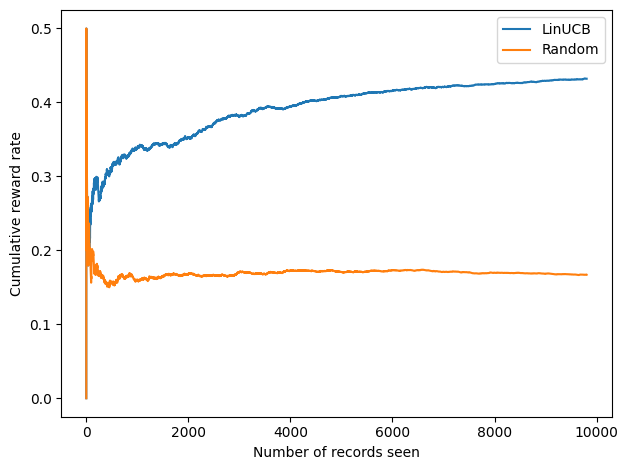

In [7]:
def get_mean_reward(rewards):
    return np.cumsum(rewards) / np.arange(1, len(rewards)+1)

fig, ax = plt.subplots()
df = pd.DataFrame({
    'LinUCB': get_mean_reward(results['bandit']['rewards']),
    'Random': get_mean_reward(results['random']['rewards']),
})
df.plot(ax=ax)
ax.set_xlabel('Number of records seen')
ax.set_ylabel('Cumulative reward rate')
plt.tight_layout()
plt.show()

In [8]:
# Map action index -> genre name (columns of arm_features are genres)
genre_names = list(arm_features.columns)

# 1) What genres does the learned policy choose overall (across records)?
bandit_action_counts = (
    pd.Series(results['bandit']['actions'], name="action_idx")
      .value_counts()
      .sort_index()
)
bandit_action_counts.index = [genre_names[i] for i in bandit_action_counts.index]
bandit_action_share = (bandit_action_counts / bandit_action_counts.sum()).rename("share").to_frame()

random_action_counts = (
    pd.Series(results['random']['actions'], name="action_idx")
      .value_counts()
      .sort_index()
)
random_action_counts.index = [genre_names[i] for i in random_action_counts.index]
random_action_share = (random_action_counts / random_action_counts.sum()).rename("share").to_frame()

policy_action_summary = bandit_action_share.join(
    random_action_share, how="outer", lsuffix="_LinUCB", rsuffix="_Random"
).fillna(0).sort_values("share_LinUCB", ascending=False)

print("\n=== Genre choices: LinUCB vs Random (share of records) ===")
print(policy_action_summary)



=== Genre choices: LinUCB vs Random (share of records) ===
             share_LinUCB  share_Random
Action           0.587540      0.049454
Drama            0.168349      0.051290
Adventure        0.092791      0.050168
Thriller         0.090650      0.050066
Comedy           0.039156      0.054859
Animation        0.007954      0.056184
Fantasy          0.005302      0.055471
IMAX             0.003365      0.057204
Mystery          0.002141      0.049251
War              0.000408      0.054757
Horror           0.000408      0.054043
Sci-Fi           0.000306      0.054145
Romance          0.000306      0.052921
Western          0.000306      0.054451
Film-Noir        0.000306      0.048435
Children         0.000204      0.049047
Documentary      0.000204      0.052004
Musical          0.000204      0.050882
Crime            0.000102      0.055369


In [9]:
# 2) Expected reward by chosen genre (empirical, from realized stream)
#    (This is just the average of realized rewards among records where a genre was chosen.)
bandit_rewards = np.asarray(results['bandit']['rewards'], dtype=float)
bandit_actions = np.asarray(results['bandit']['actions'], dtype=int)

avg_reward_by_genre = (
    pd.DataFrame({"genre": [genre_names[i] for i in bandit_actions],
                  "reward": bandit_rewards})
      .groupby("genre")["reward"]
      .mean()
      .sort_values(ascending=False)
      .rename("avg_reward")
      .to_frame()
)

print("\n=== Average realized reward by chosen genre (LinUCB stream) ===")
print(avg_reward_by_genre)



=== Average realized reward by chosen genre (LinUCB stream) ===
             avg_reward
genre                  
Action         0.470670
Adventure      0.407692
Drama          0.407026
Thriller       0.381327
Comedy         0.317708
IMAX           0.121212
Animation      0.115385
Fantasy        0.115385
Mystery        0.095238
Documentary    0.000000
Children       0.000000
Horror         0.000000
Film-Noir      0.000000
Crime          0.000000
Musical        0.000000
Romance        0.000000
Sci-Fi         0.000000
War            0.000000
Western        0.000000


In [10]:
# 3) Policy at the USER level: what genre would LinUCB choose for each user context?
#    (One prediction per user)
X_users = user_features.values
user_level_actions = bandit.predict(X_users)

user_policy = (
    pd.Series(user_level_actions, index=user_features.index, name="action_idx")
      .map(lambda i: genre_names[i])
      .rename("chosen_genre")
      .to_frame()
)

print("\n=== Most common chosen genre at USER level ===")
print(user_policy["chosen_genre"].value_counts())

# Look at a few users: their top genres vs chosen genre
top_k = 5
user_top_genres = (
    user_features.apply(lambda row: list(row.sort_values(ascending=False).head(top_k).index), axis=1)
                 .rename("top_genres")
                 .to_frame()
)
user_inspect = user_policy.join(user_top_genres)
print("\n=== Sample users: chosen genre vs their top-5 historical genres ===")
print(user_inspect.sample(10, random_state=0))


=== Most common chosen genre at USER level ===
chosen_genre
Action    583
Name: count, dtype: int64

=== Sample users: chosen genre vs their top-5 historical genres ===
       chosen_genre                                    top_genres
userId                                                           
258          Action   [Adventure, Drama, Action, Sci-Fi, Fantasy]
98           Action    [Drama, Comedy, Adventure, Action, Sci-Fi]
403          Action      [Drama, Comedy, Action, Thriller, Crime]
198          Action    [Drama, Comedy, Sci-Fi, Thriller, Romance]
407          Action  [Action, Adventure, Thriller, Sci-Fi, Drama]
109          Action    [Drama, Comedy, Thriller, Romance, Action]
531          Action    [Adventure, Action, Comedy, Drama, Sci-Fi]
16           Action      [Drama, Comedy, Thriller, Action, Crime]
56           Action  [Action, Thriller, Drama, Comedy, Adventure]
521          Action     [Drama, Comedy, Thriller, Romance, Crime]


In [11]:
ovr = bandit._oracles
nchoices = bandit.nchoices

# per-arm models
models = [ovr.algos[a].model for a in range(bandit.nchoices)]

# stack coefs (nchoices x 20)
coef = np.vstack([m.coef_.ravel() for m in models])

# name rows (actions) and columns (features + intercept)
action_names = getattr(bandit, "choice_names", None)
if action_names is None or len(action_names) != nchoices:
    action_names = list(arm_features.columns)   # in your code: genres/actions

feat_names = list(user_features.columns) + ["intercept"]

theta_df = pd.DataFrame(coef, index=action_names, columns=feat_names)
theta_df.head()

,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,intercept
Action,5.209595,-0.640625,-2.806641,1.718262,1.195312,-2.180176,3.800293,-0.422363,0.539551,2.068848,0.460449,-13.950684,2.025879,0.702148,0.235352,0.846680,1.716797,-2.294922,-0.128906,2.424969
Adventure,0.841675,-0.147095,1.403137,0.993958,-0.046509,0.694946,-3.909363,-0.152100,1.937866,-3.329712,0.257568,-5.328003,-0.684448,2.555908,1.404785,1.513916,-1.373535,2.274658,0.928223,0.093115
Animation,-0.346336,-1.610821,1.073376,1.951233,-0.406891,0.817341,-0.517169,-1.532486,-0.287102,-0.129296,-1.165699,-0.370865,-2.219143,-0.583981,1.665131,2.078110,1.564240,1.197115,-1.002880,0.179051
Children,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Comedy,1.531158,-1.445374,1.189026,0.177368,-0.185364,-0.117065,3.862320,0.114258,-0.299683,-0.425812,-1.561157,-1.332323,1.075439,0.280090,-0.297180,0.518738,-0.745911,-1.673950,-0.228821,0.316635


In [12]:
print(theta_df)

               Action  Adventure  Animation  Children    Comedy     Crime  \
Action       5.209595  -0.640625  -2.806641  1.718262  1.195312 -2.180176   
Adventure    0.841675  -0.147095   1.403137  0.993958 -0.046509  0.694946   
Animation   -0.346336  -1.610821   1.073376  1.951233 -0.406891  0.817341   
Children     0.000000   0.000000   0.000000  0.000000  0.000000  0.000000   
Comedy       1.531158  -1.445374   1.189026  0.177368 -0.185364 -0.117065   
Crime        0.000000   0.000000   0.000000  0.000000  0.000000  0.000000   
Documentary  0.000000   0.000000   0.000000  0.000000  0.000000  0.000000   
Drama        0.062500   0.455322  -0.620605  2.046265  0.394165  1.240112   
Fantasy      0.511593  -0.472252  -0.209861  2.083347 -2.985447 -0.149277   
Film-Noir    0.000000   0.000000   0.000000  0.000000  0.000000  0.000000   
Horror       0.000000   0.000000   0.000000  0.000000  0.000000  0.000000   
IMAX         2.721134   0.292294  -0.644241  1.126495 -0.300911 -2.289276   

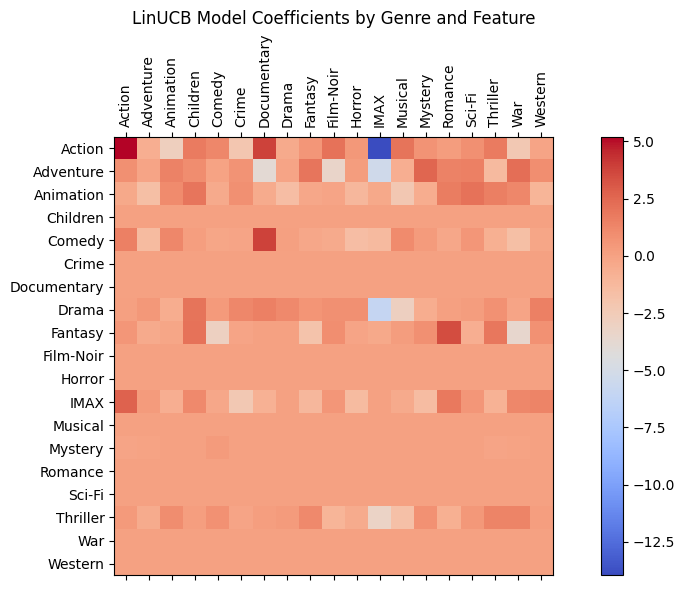

In [13]:
# Visualize the coefficients as a heatmap
theta_viz = theta_df.drop(columns=['intercept'])
feat_viz_names = theta_viz.columns

fig, ax = plt.subplots(figsize=(10, 6))
cax = ax.matshow(theta_viz, cmap='coolwarm')
fig.colorbar(cax)
ax.set_xticks(np.arange(len(feat_viz_names)))
ax.set_yticks(np.arange(len(action_names)))
ax.set_xticklabels(feat_viz_names, rotation=90)
ax.set_yticklabels(action_names)
ax.set_title('LinUCB Model Coefficients by Genre and Feature')
plt.tight_layout()
plt.show()


In [14]:
X = user_features.values
baseline = bandit.decision_function(X).mean(axis=0)

eps = 0.05
sens = {}

for j, feat in enumerate(user_features.columns):
    Xp = X.copy()
    Xp[:, j] += eps
    delta = bandit.decision_function(Xp).mean(axis=0) - baseline
    sens[feat] = delta

sens_df = pd.DataFrame(sens, index=action_names)

# show top features per action
for a in action_names:
    print(f"\n=== Action: {a} ===")
    display(sens_df.loc[a].sort_values(ascending=False))


=== Action: Action ===


,Action
Action,0.266224
Documentary,0.198043
Film-Noir,0.120066
Musical,0.108531
Children,0.092786
Thriller,0.091692
Comedy,0.065263
Sci-Fi,0.048285
Mystery,0.042535
Fantasy,0.033530



=== Action: Adventure ===


,Adventure
Mystery,0.136945
War,0.119093
Fantasy,0.101485
Sci-Fi,0.079723
Animation,0.078787
Romance,0.074202
Children,0.055488
Western,0.052986
Action,0.047065
Crime,0.041205



=== Action: Animation ===


...

,Thriller
War,0.076214
Thriller,0.071976
Fantasy,0.063148
Animation,0.059294
Mystery,0.045306
Comedy,0.041003
Sci-Fi,0.025264
Action,0.022853
Documentary,0.021813
Drama,0.019902



=== Action: War ===


,War
Animation,0.015849
Sci-Fi,0.014852
IMAX,0.014082
Fantasy,0.013660
Horror,0.013376
Musical,0.013054
Mystery,0.012223
Documentary,0.011113
Adventure,0.010724
Film-Noir,0.009620



=== Action: Western ===


,Western
Animation,0.015221
Fantasy,0.014406
IMAX,0.013537
Sci-Fi,0.013363
Musical,0.012459
Children,0.011584
Horror,0.011471
Documentary,0.010574
Mystery,0.010497
Adventure,0.010011


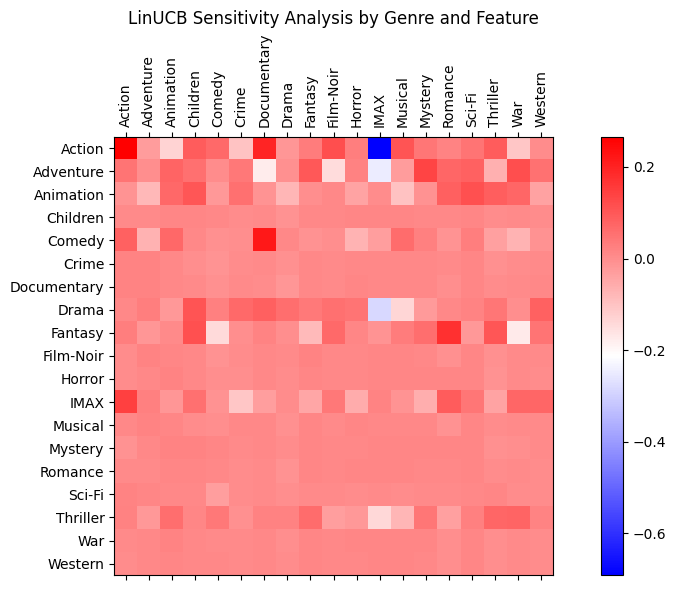

In [15]:
# Visualize the sensitivity as a heatmap
fig, ax = plt.subplots(figsize=(10, 6))
cax = ax.matshow(sens_df, cmap='bwr')
fig.colorbar(cax)
ax.set_xticks(np.arange(len(user_features.columns)))
ax.set_yticks(np.arange(len(action_names)))
ax.set_xticklabels(user_features.columns, rotation=90)
ax.set_yticklabels(action_names)
ax.set_title('LinUCB Sensitivity Analysis by Genre and Feature')
plt.tight_layout()
plt.show()
